# Generalized SVGD

In [12]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from generalized_svgd import GeneralizedSVGD
import functions as f

import jax
from jax import random

In [13]:
device_name = "cpu"

# KGD kernel :  IMQ   : $k(x,y) = \frac{1}{\sqrt{c + \|x-y\|^2}}$. 
# SVGD kernel : Gaussian  : $m(x,y) = e^{-\|x-y\|^2/(2\sigma_m^2)}$.

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [14]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) / jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)


k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)
m = jit(m)
dm = jit(dm)


G_SVGD= GeneralizedSVGD(q_0,L,k,m,dm)

In [18]:
T = 500
n = 50
d = 2
n_sim = 1

Eta = jnp.array([0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0,4.0])
device = jax.devices(device_name)[0]  

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key, shape) + 5 * jnp.ones((n, d))
        #X0 = jax.device_put(X0, device)
        all_particles = G_SVGD.run_particles(eta, T, X0)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])
        

In [16]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(G_SVGD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))

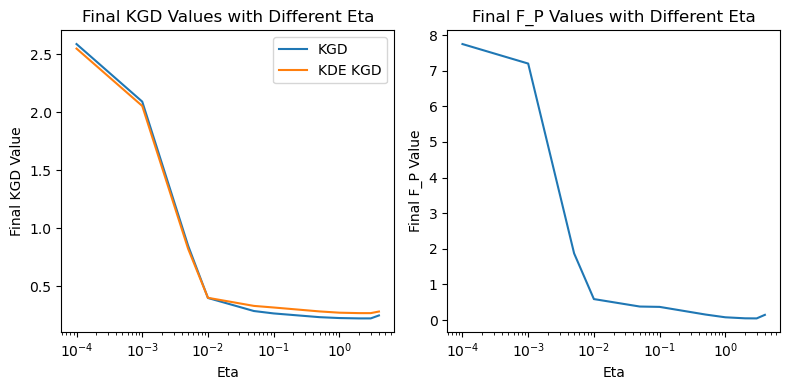

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin,label ='KGD')
axes[0].plot(Eta, KDE_KGD_fin,label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')   
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

plt.tight_layout()
plt.show()


In [11]:
KGD_fin

Array([2.5857568 , 2.0905259 , 0.8498078 , 0.40104613, 0.2887893 ,
       0.2680834 , 0.2359007 , 0.22835174, 0.22525886, 0.22531933,
       0.25067186], dtype=float32)

# 2. Linear + Quadratic term 

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x) + \int \int w(x,x') \ d Q(x) d Q(x)$, with $v(x) = 1/2 \|x\|^2$ and $w(x,x') = x^Tx'$.

<!-- if w= 0
F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->

In [44]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) / jnp.sqrt((2  *jnp.pi)**d)
def v(x):
    return -1/4 * jnp.linalg.norm(x,axis = 1)**2
def w(X):
    _X = jax.lax.stop_gradient(X).T
    return jnp.dot(X,_X)
def L(X):
     return np.mean(v(X)) + np.mean(w(X))

sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)
m = jit(m)
dm = jit(dm)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)

In [54]:
T = 500
n = 50
d = 2
n_sim = 1

Eta = jnp.array([0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0,1.1,1.2])
device = jax.devices(device_name)[0]  

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key, shape) + 5 * jnp.ones((n, d))
        X0 = jax.device_put(X0, device)
        all_particles = G_SVGD.run_particles(eta, T, X0)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

In [55]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(G_SVGD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))

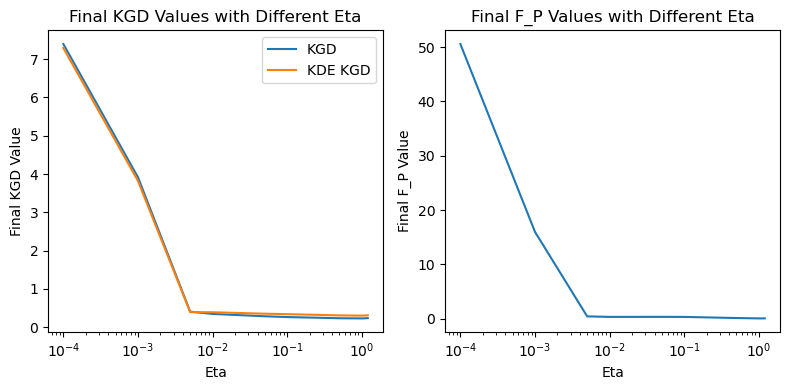

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin,label ='KGD')
axes[0].plot(Eta, KDE_KGD_fin,label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')   
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

plt.tight_layout()
plt.show()

In [57]:
KGD_fin

Array([7.3928986 , 3.9145873 , 0.40950483, 0.34866518, 0.28804588,
       0.26769635, 0.23670739, 0.23244664, 0.23479308, 0.24081789],      dtype=float32)

# 3. MMD

### a) Q_1 is a Gaussian
- $\mathcal{L}(Q) = \frac{\gamma}{2} \textrm{MMD}(Q,Q_1)^2$
- $Q_1 = \mathcal{N}(\mu,\Sigma)$ where $\mu = (5,5)$, $\Sigma = I_d$
- Gaussian kernel in the MMD: $l(x,x') = \exp(-\frac{\|x-x'\|^2}{2 \sigma_l^2})$

In [58]:
c = 1.0
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y))) #(x-y,x-y)/(2*c**2))

#x2 = jnp.array([5,5])
def q_0(x):
    return jnp.exp(-jnp.dot(x,x)/(2*4)) / jnp.sqrt((2* 4  *jnp.pi)**d)

sigma_l = 3.0
l = lambda x,y : ker.k_gauss(x,y,sigma_l) #Gram matrix for gaussian kernel = shape (n,m)

d = 2
Cov = np.diag(jnp.ones(d))
n1 = 70
mu = 5*np.ones(d)

key = random.PRNGKey(98)  
shape1 = (n1, d)
X1 = random.multivariate_normal(key,mu,Cov,n1)

gamma = 10
def L(X):
    _X = jax.lax.stop_gradient(X)
    return gamma/2 * (np.mean(l(X,_X)) - 2 * np.mean(l(X,X1)) + np.mean(l(X1,X1)))


sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

k = jit(k)  
q_0 = jit(q_0)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)

In [66]:
T = 500
n = 50
d = 2
n_sim = 1

Eta = jnp.array([0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0,2.0,3.0,5.0,10.0])
device = jax.devices(device_name)[0]  

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key, shape) + 5 * jnp.ones((n, d))
        X0 = jax.device_put(X0, device)
        all_particles = G_SVGD.run_particles(eta, T, X0)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

In [ ]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(G_SVGD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
L_fin = L_fin.at[e].set(L(X))

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))
    L_fin = L_fin.at[e].set(L(X))

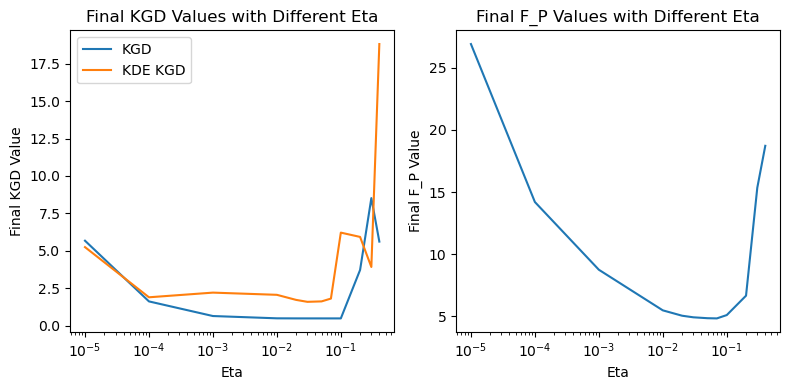

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin,label ='KGD')
axes[0].plot(Eta, KDE_KGD_fin,label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')   
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')




plt.tight_layout()
plt.show()

# 4 Neural Network learning : $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$. The learning function $\psi$ is a two layer neural network. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from generalized_svgd import GeneralizedSVGD
import jax_kernels as ker
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random
import functions as f

from jax.flatten_util import ravel_pytree
from jax import grad, random,vmap,tree_util

In [2]:
# from jax import grad, random,vmap,tree_util
# from jax.flatten_util import ravel_pytree

# def init_params(rng, input_dim, hidden_dim):
#     rng1, rng2,rng3,rng4 = random.split(rng,4)
#     params = {
#         'W1': (random.uniform(rng1, (hidden_dim, input_dim))-0.5) * 10.0 ,
#         'b1': random.normal(rng4, (hidden_dim,)),
#         'W2': (random.uniform(rng2, (1, hidden_dim))- 0.5) * 10.0 ,
#         'b2': random.normal(rng3, (1,)) 
#     }
#     return params

# # 

# @jit
# def forward(params, z):
#     h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
#     y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
#     return y.squeeze()


In [3]:

def generate_data(key, s, N, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]

    #explanation function
    def f(z):
        return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

N = 500
s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N, noise_std=0.1) # put more noise
#plt.plot(Z,Y,".")

$k$, $q_0$ and $\mathcal{L}$

In [4]:
kernel_name = "IMQ"
c = jnp.array(1.0)
b = 3.0
def k(x,y):
    return (c**2 + (x-y).dot(x-y))**(-b)
    #return jnp.dot(x,y)

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*4)) #/ jnp.sqrt((2 * jnp.pi)**d)


key = random.PRNGKey(0)
model = f.MLP(hidden_dims=[1], output_dim=1)
params = model.init(key, jnp.ones((s,)))  
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)  
#lambd = 0.1


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : model.apply(unravel_fn(x), z)))(X))
    return E
gamma = 100
def L(X):  
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

m = lambda x,y : ker.k_gauss(x, y, sigma=5.0)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=5.0)

k = jit(k)
q_0 = jit(q_0)
esp_forward = jit(esp_forward)
L = jit(L)  
m = jit(m)
dm = jit(dm)
 
G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)   

In [5]:
T = 10000
n = 50

Eta = jnp.logspace(-5,-1,15)   #jnp.array([1e-5,1e-4,0.001,0.01,0.02,0.03,0.05,0.07,0.1])#jnp.logspace(-6,-2,10)


n_sim = 1
all_particles_fin = jnp.zeros((len(Eta), n, d))

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(200 + sim)
        key = random.PRNGKey(3+n_sim)
        shape = (n, d)
        X_list = [model.init(random.fold_in(key_init, i),jnp.ones((s,))) for i in range(n)]
        flat_X_list = [ravel_pytree(p)[0] for p in X_list]  
        X0 = jnp.stack(flat_X_list)
        #name_data = f"all_particles_kernel_name{kernel_name}_c{c}_hidden_dim{hidden_dim}_N{N}_eta{eta}_T{T}_n{n}_d{d}.npy"
        all_particles = G_SVGD.run_particles(eta, T, X0)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])


In [6]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(G_SVGD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jnp.zeros(len(Eta))
KDE_KGD_fin = jnp.zeros(len(Eta))
F_P_fin = jnp.zeros(len(Eta))
L_fin = jnp.zeros(len(Eta))

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X,num_samples = 300))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X,num_samples = 300))
    L_fin = L_fin.at[e].set(L(X))

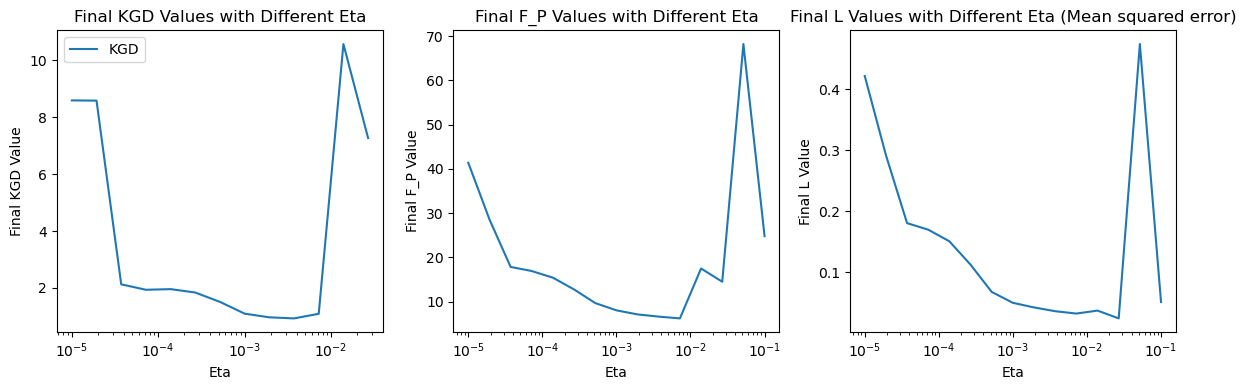

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta[:-2], KGD_fin[:-2], label='KGD')
#axes[0].plot(Eta, KDE_KGD_fin, label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
#axes[0].set_ylim(0.4, 1.5)
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

axes[2].plot(Eta, 1/gamma * L_fin)
axes[2].set_xlabel('Eta')
axes[2].set_ylabel('Final L Value')
axes[2].set_xscale('log')
axes[2].set_title('Final L Values with Different Eta (Mean squared error)')

plt.tight_layout()
plt.show()

In [8]:
print(KGD_fin)
print(F_P_fin)

[ 8.593718    8.585892    2.1262763   1.9350935   1.9574772   1.8377656
  1.5083243   1.0952078   0.96625584  0.92821723  1.0902265  10.575077
  7.2698603   3.2684832   1.9883832 ]
[41.37626   28.572285  17.830118  16.90298   15.395999  12.733876
  9.657435   8.015903   7.0904326  6.594009   6.1915083 17.477013
 14.484067  68.226234  24.792135 ]


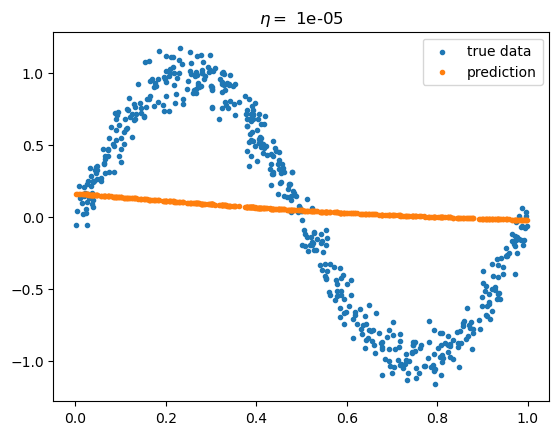

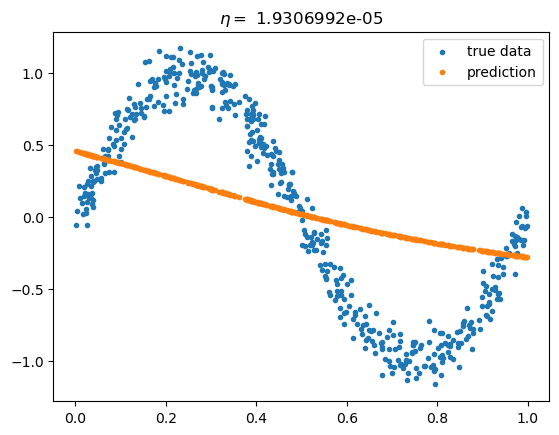

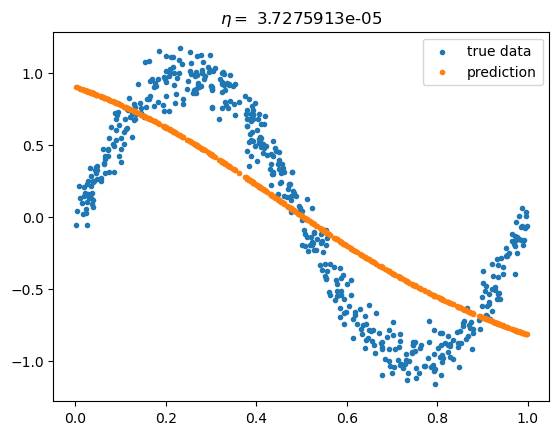

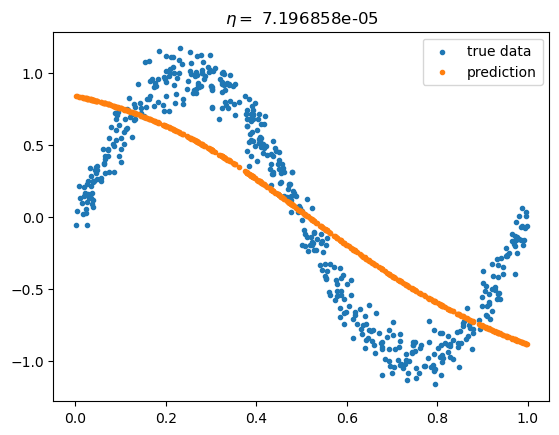

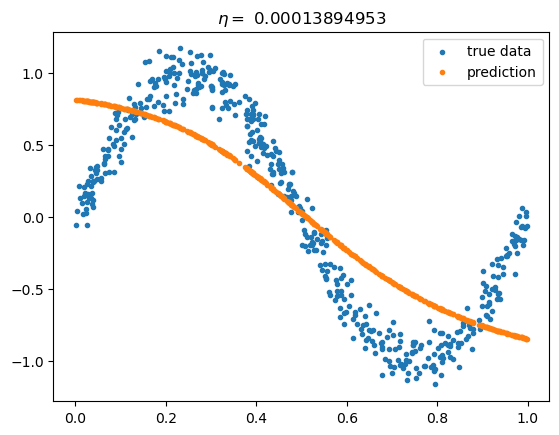

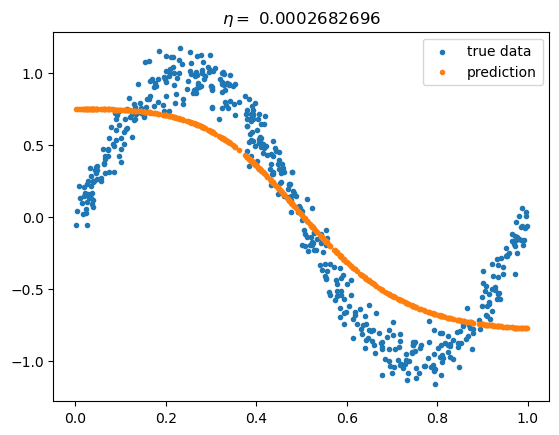

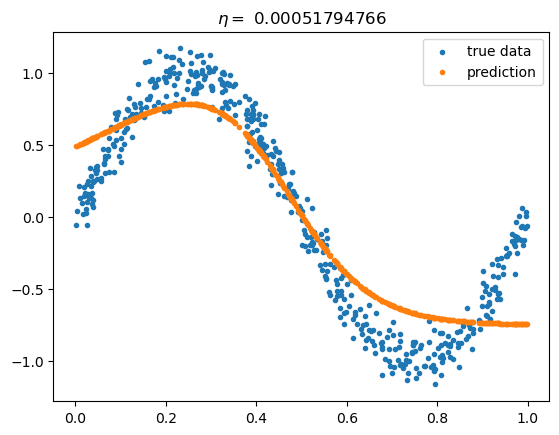

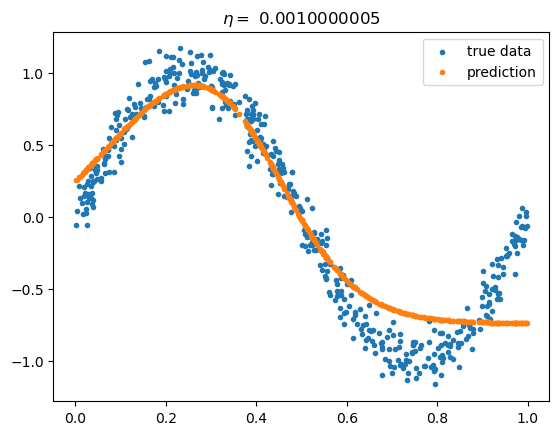

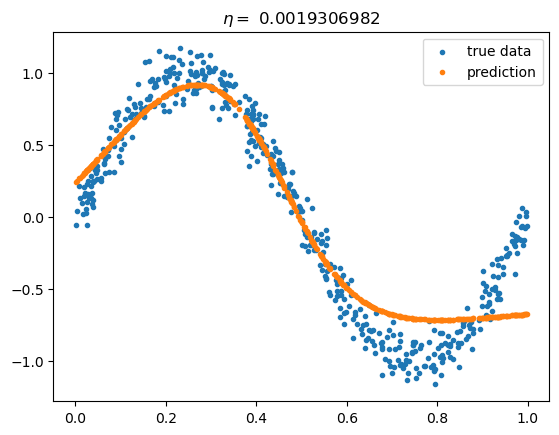

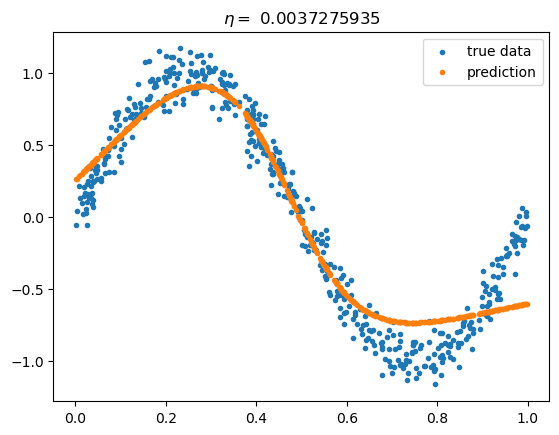

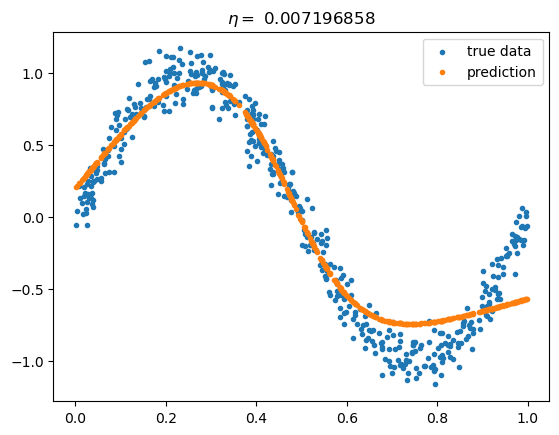

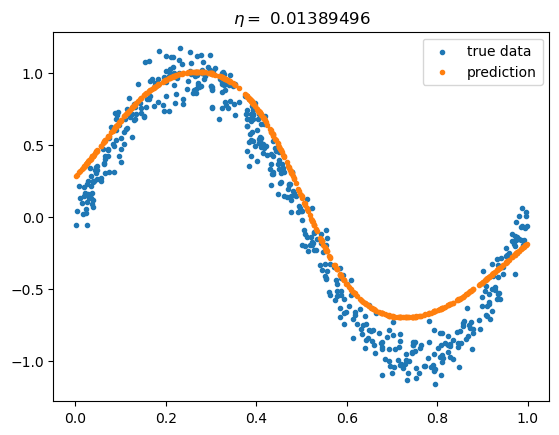

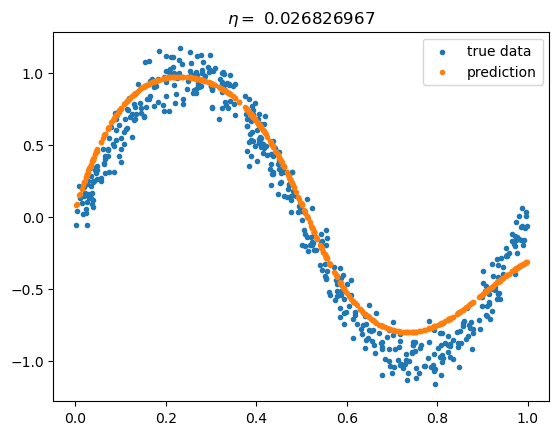

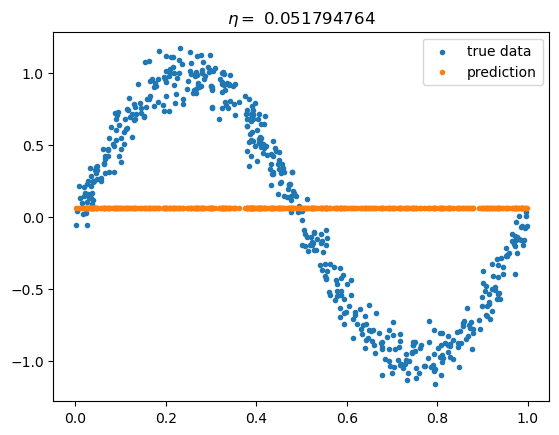

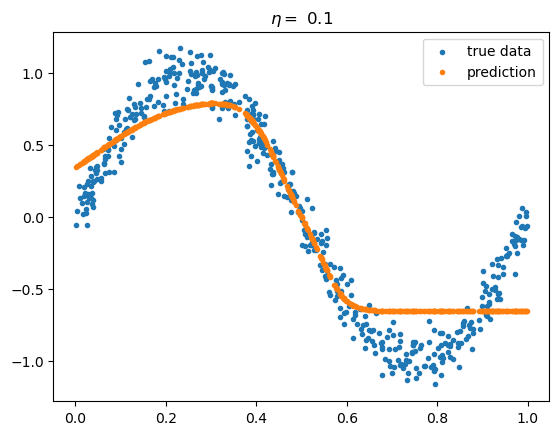

In [9]:
for e in range(len(Eta)):
    plt.figure()
    plt.scatter(Z,Y,label = "true data",marker = ".")
    X_fin = all_particles_fin[e]
    Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
    plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
    plt.legend()
    plt.title(r"$\eta = $ " + str(Eta[e]))


In [101]:
KGD_fin

Array([5.678842  , 1.6263659 , 0.6499062 , 0.49690655, 0.492502  ,
       0.49171695, 0.491472  , 0.49143732, 0.49140775, 3.7264204 ,
       8.522243  , 5.6197324 ,        nan], dtype=float32)